<a href="https://colab.research.google.com/github/benman17/NFL-Clustering/blob/main/notebooks/NFL_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **NFL Tier Based Clustering**

The aim of this project is to create a model to classify players into certain tiers/clusters of importance for casual fantasy football players going to draft their teams.

## **Data Collection**

Collect primary data using the sportsdata.io API

In [ ]:
# Install required packages if needed
!pip install requests pandas scikit-learn

In [ ]:
# Import necessary libraries
import requests
import pandas as pd

# API configuration
url = "https://api.sportsdata.io/v3/nfl/stats/json/PlayerSeasonStats/2024?key=fa611065a79a4d88bee45f6d80c6c4fe"

response = requests.get(url)
data = response.json()

# Build DataFrame including only the statistics used to calculate fantasy points and identify players
df = pd.DataFrame({
    'Name': [p.get('Name') for p in data],
    'Team': [p.get('Team') for p in data],
    'Position': [p.get('Position') for p in data],
    'PassingYards': [p.get('PassingYards', 0) for p in data],
    'PassingTouchdowns': [p.get('PassingTouchdowns', 0) for p in data],
    'PassingInterceptions': [p.get('PassingInterceptions', 0) for p in data],
    'RushingYards': [p.get('RushingYards', 0) for p in data],
    'RushingTouchdowns': [p.get('RushingTouchdowns', 0) for p in data],
    'ReceivingYards': [p.get('ReceivingYards', 0) for p in data],
    'ReceivingTouchdowns': [p.get('ReceivingTouchdowns', 0) for p in data],
    'Receptions': [p.get('Receptions', 0) for p in data],
    'FumblesLost': [p.get('FumblesLost', 0) for p in data],
    'Tackles': [p.get('Tackles', 0) for p in data],
    'Sacks': [p.get('Sacks', 0) for p in data],
    'Interceptions': [p.get('Interceptions', 0) for p in data],
    'ForcedFumbles': [p.get('ForcedFumbles', 0) for p in data],
    'DefensiveTouchdowns': [p.get('DefensiveTouchdowns', 0) for p in data],
})

## **Data Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255 entries, 0 to 2254
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  2255 non-null   object 
 1   Team                  2255 non-null   object 
 2   Position              2255 non-null   object 
 3   PassingYards          2255 non-null   float64
 4   PassingTouchdowns     2255 non-null   float64
 5   PassingInterceptions  2255 non-null   float64
 6   RushingYards          2255 non-null   float64
 7   RushingTouchdowns     2255 non-null   float64
 8   ReceivingYards        2255 non-null   float64
 9   ReceivingTouchdowns   2255 non-null   float64
 10  Receptions            2255 non-null   float64
 11  FumblesLost           2255 non-null   float64
 12  Tackles               2255 non-null   float64
 13  Sacks                 2255 non-null   float64
 14  Interceptions         2255 non-null   float64
 15  ForcedFumbles        

In [ ]:
# Check the unique positions pulled from the api
df['Position'].unique()

array(['K', 'QB', 'TE', 'DT', 'LS', 'P', 'S', 'DE', 'OT', 'LB', 'OL',
       'CB', 'G', 'ILB', 'WR', 'FB', 'RB', 'DL', 'OLB', 'C', 'FS', 'DB',
       'NT', 'SS'], dtype=object)

In [ ]:
# Drop positions that cannot score fantasy points in any format
df = df[~df['Position'].isin(['LS', 'P', 'OL', 'G', 'C', 'OT', 'K'])]

In [ ]:
# Change fullbacks to runningbacks, since that will almost always be their classification on fantasy sites
df['Position'] = df['Position'].replace({'FB': 'RB'})

# Make sure all linebackers have the same position
df['Position'] = df['Position'].replace({'OLB': 'LB', 'ILB': 'LB'})

# Make sure all DL have the same position
df['Position'] = df['Position'].replace({'NT': 'DL', 'DT': 'DL', 'DE': 'DL'})

# Make sure all DB have the same position
df['Position'] = df['Position'].replace({'CB': 'DB', 'SS': 'DB', 'FS': 'DB', 'S': 'DB'})

In [ ]:
# Check the unique positions pulled from the api
df['Position'].unique()

array(['QB', 'TE', 'DL', 'DB', 'LB', 'WR', 'RB'], dtype=object)

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Name,0
Team,0
Position,0
PassingYards,0
PassingTouchdowns,0
PassingInterceptions,0
RushingYards,0
RushingTouchdowns,0
ReceivingYards,0
ReceivingTouchdowns,0


Though we could set thresholds for something like games played, players do get injured and some of them are important to the model and making decisions for the next year's draft. As such, we have held off on setting such thresholds for this project

In [ ]:
# When position is QB, check for 0 passing yards
df_qb_drop = df[(df['Position'] == 'QB') & (df['PassingYards'] == 0)]

# Drop the rows in df_qb_drop using their indices
df = df.drop(df_qb_drop.index)

In [ ]:
# When position is rb, check for 0 rushing yards
df_rb_drop = df[(df['Position'] == 'RB') & (df['RushingYards'] == 0)]

# Drop the rows in df_rb_drop using their indices
df = df.drop(df_rb_drop.index)

In [ ]:
# When position is wr, check for 0 receiving yards
df_wr_drop = df[(df['Position'] == 'WR') & (df['ReceivingYards'] == 0)]

# Drop the rows in df_wr_drop using their indices
df = df.drop(df_wr_drop.index)

In [ ]:
# When position is te, check for 0 receiving yards
df_te_drop = df[(df['Position'] == 'TE') & (df['Receptions'] == 0)]

# Drop the rows in df_te_drop using their indices
df = df.drop(df_te_drop.index)

In [ ]:
# When position is lb, check for 0 tackles
df_lb_drop = df[(df['Position'] == 'LB') & (df['Tackles'] == 0)]

# Drop the rows in df_lb_drop using their indices
df = df.drop(df_lb_drop.index)

In [ ]:
# When position is dl, check for 0 tackles
df_dl_drop = df[(df['Position'] == 'DL') & (df['Tackles'] == 0)]

# Drop the rows in df_dl_drop using their indices
df = df.drop(df_dl_drop.index)

In [ ]:
# When position is db, check for 0 tackles
df_db_drop = df[(df['Position'] == 'DB') & (df['Tackles'] == 0)]

# Drop the rows in df_db_drop using their indices
df = df.drop(df_db_drop.index)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1481 entries, 1 to 2253
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  1481 non-null   object 
 1   Team                  1481 non-null   object 
 2   Position              1481 non-null   object 
 3   PassingYards          1481 non-null   float64
 4   PassingTouchdowns     1481 non-null   float64
 5   PassingInterceptions  1481 non-null   float64
 6   RushingYards          1481 non-null   float64
 7   RushingTouchdowns     1481 non-null   float64
 8   ReceivingYards        1481 non-null   float64
 9   ReceivingTouchdowns   1481 non-null   float64
 10  Receptions            1481 non-null   float64
 11  FumblesLost           1481 non-null   float64
 12  Tackles               1481 non-null   float64
 13  Sacks                 1481 non-null   float64
 14  Interceptions         1481 non-null   float64
 15  ForcedFumbles         1481

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Name,0
Team,0
Position,0
PassingYards,0
PassingTouchdowns,0
PassingInterceptions,0
RushingYards,0
RushingTouchdowns,0
ReceivingYards,0
ReceivingTouchdowns,0


## **Feature Creation**

### **Fantasy Points Calculation**

In [ ]:
# Define Custom Fantasy Scoring Function for Standard PPR, IDP
def calculate_projected_fantasy_points(row):
    pass_yds = row.get('PassingYards', 0)
    pass_td = row.get('PassingTouchdowns', 0)
    interceptions = row.get('PassingInterceptions', 0)
    rush_yds = row.get('RushingYards', 0)
    rush_td = row.get('RushingTouchdowns', 0)
    rec_yds = row.get('ReceivingYards', 0)
    rec_td = row.get('ReceivingTouchdowns', 0)
    receptions = row.get('Receptions', 0)
    fumbles = row.get('FumblesLost', 0)

    tackles = row.get('Tackles', 0)
    sacks = row.get('Sacks', 0)
    int_def = row.get('Interceptions', 0)
    forced_fumbles = row.get('ForcedFumbles', 0)
    def_td = row.get('DefensiveTouchdowns', 0)

    fantasy_points = 0
    fantasy_points += pass_yds / 25
    fantasy_points += pass_td * 4
    fantasy_points -= interceptions * 2
    fantasy_points += rush_yds / 10
    fantasy_points += rush_td * 6
    fantasy_points += rec_yds / 10
    fantasy_points += rec_td * 6
    fantasy_points += receptions * 1
    fantasy_points -= fumbles * 2

    fantasy_points += tackles * 1
    fantasy_points += sacks * 2
    fantasy_points += int_def * 3
    fantasy_points += forced_fumbles * 2
    fantasy_points += def_td * 6

    return round(fantasy_points, 2)

# Apply the function to get the new target
df['CalculatedFantasyPoints_StdPPPRIDP'] = df.apply(calculate_projected_fantasy_points, axis=1)

print(df)

              Name Team Position  PassingYards  PassingTouchdowns  \
1         J.Flacco  IND       QB         722.0                2.0   
2        A.Rodgers  NYJ       QB        1597.8               11.5   
3          M.Lewis  CHI       TE           0.0                0.0   
4       C.Campbell  MIA       DL           0.0                0.0   
5        J.Johnson  BAL       QB           2.9                0.0   
...            ...  ...      ...           ...                ...   
2249     S.Bozeman   KC       LB           0.0                0.0   
2250  B.Codrington  BUF       DB           0.0                0.0   
2251     E.Chatman  NYG       DL           0.0                0.0   
2252  J.Andreessen  BUF       LB           0.0                0.0   
2253     D.Tillman  DEN       LB           0.0                0.0   

      PassingInterceptions  RushingYards  RushingTouchdowns  ReceivingYards  \
1                      1.2          10.7                0.0             0.0   
2            

### **Value over Replacement Feature**

In [ ]:
# Begin by creating a term to calculate relative quality over replacement to account
# for position scarcity in terms of the drop-off in the availability of elite quality players

# Begin by setting replacement thresholds, which should be the last starter for each position in the league
# These are those thresholds assuming a standard 12 man, PPR-IDP league
replacement_ranks = {
    # Offensive positions
    'QB': 12, # One qb starter per team
    'RB': 30, # 2 rb starters and 1 flex (half)
    'WR': 42, # 3 wide receiver starters and 1 flex (half)
    'TE': 12, # 1 tight end starter

    # IDP positions
    'LB': 36, # 3 lbs per team
    'DL': 24, # 2 dl per team
    'DB': 30 # 2-3 DB per team
}

# Initialize replacement point values
replacement_points = {}

# Calculate replacement-level points for each position
for pos, rank in replacement_ranks.items():
    # Filter players by position
    pos_df = df[df['Position'] == pos].sort_values(by='CalculatedFantasyPoints_StdPPPRIDP', ascending=False).reset_index(drop=True)

    if len(pos_df) >= rank:
        # Find the replacement-level player (the player at rank-1)
        replacement_value = pos_df.loc[rank - 1, 'CalculatedFantasyPoints_StdPPPRIDP']
    else:
        # If there aren't enough players for this position, use the lowest fantasy points as replacement value
        replacement_value = pos_df['CalculatedFantasyPoints_StdPPPRIDP'].min()

    # Store the replacement value for this position
    replacement_points[pos] = replacement_value

# Now map replacement points to the main DataFrame
df['replacement_points'] = df['Position'].map(replacement_points)

print(df[['Name', 'Position', 'CalculatedFantasyPoints_StdPPPRIDP', 'replacement_points']].head(20))

            Name Position  CalculatedFantasyPoints_StdPPPRIDP  \
1       J.Flacco       QB                               34.35   
2      A.Rodgers       QB                              110.10   
3        M.Lewis       TE                                0.23   
4     C.Campbell       DL                               22.90   
5      J.Johnson       QB                                0.14   
6     M.Stafford       QB                               73.78   
11     K.Jackson       DB                                0.50   
13      J.Hughes       DL                                0.80   
14      L.Joseph       DL                                3.80   
15      B.Graham       DL                                4.60   
18     N.Bellore       LB                                1.20   
19      T.Taylor       QB                                4.17   
20      A.Dalton       QB                               20.41   
21     C.Heyward       DL                               31.70   
22      V.Miller       LB

In [ ]:
# Before calculating VOR, double-check the values of the columns
print(df[['Name', 'Position', 'CalculatedFantasyPoints_StdPPPRIDP', 'replacement_points']].head(20))

# Calculate VOR
df['VOR'] = df['CalculatedFantasyPoints_StdPPPRIDP'] - df['replacement_points']

# Check the results after VOR calculation
print(df[['Name', 'Position', 'CalculatedFantasyPoints_StdPPPRIDP', 'replacement_points', 'VOR']].head(20))

            Name Position  CalculatedFantasyPoints_StdPPPRIDP  \
1       J.Flacco       QB                               34.35   
2      A.Rodgers       QB                              110.10   
3        M.Lewis       TE                                0.23   
4     C.Campbell       DL                               22.90   
5      J.Johnson       QB                                0.14   
6     M.Stafford       QB                               73.78   
11     K.Jackson       DB                                0.50   
13      J.Hughes       DL                                0.80   
14      L.Joseph       DL                                3.80   
15      B.Graham       DL                                4.60   
18     N.Bellore       LB                                1.20   
19      T.Taylor       QB                                4.17   
20      A.Dalton       QB                               20.41   
21     C.Heyward       DL                               31.70   
22      V.Miller       LB

In [ ]:
# Sort df by 'VOR'
df = df.sort_values(by='VOR', ascending=True)

# Reset the index
df = df.reset_index(drop=True)

In [ ]:
# Print a data frame with 'Name', 'Team', Position', 'CalculatedFantasyPoints_StdPPPRIDP', and 'VOR'
df[['Name', 'Team', 'Position', 'CalculatedFantasyPoints_StdPPPRIDP', 'VOR']].head(20)

,Name,Team,Position,CalculatedFantasyPoints_StdPPPRIDP,VOR
0,C.Tune,ARI,QB,-0.51,-97.89
1,T.Bagent,CHI,QB,-0.22,-97.60
2,K.Trask,TB,QB,-0.13,-97.51
3,S.Howell,SEA,QB,-0.01,-97.39
4,K.Allen,PIT,QB,0.13,-97.25
5,J.Johnson,BAL,QB,0.14,-97.24
6,M.White,BUF,QB,0.46,-96.92
7,N.Mullens,MIN,QB,0.54,-96.84
8,T.Heinicke,LAC,QB,0.80,-96.58
9,H.Hooker,DET,QB,1.05,-96.33


### **Data Reduction Given Statistical Distribution in Context**

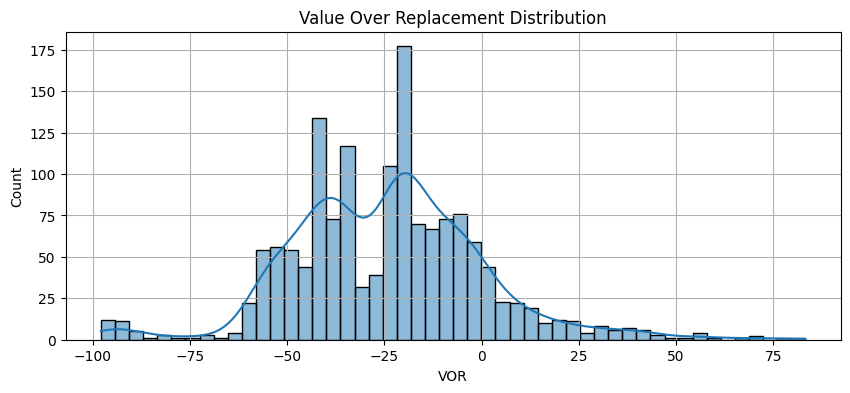

In [ ]:
# Check VOR distribution to eliminate players who either did not play enough
# or whose VOR is so low its unreasonable
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot VOR
plt.figure(figsize=(10, 4))
sns.histplot(df['VOR'], bins=50, kde=True)
plt.title('Value Over Replacement Distribution')
plt.xlabel('VOR')
plt.ylabel('Count')
plt.grid(True)
plt.show()

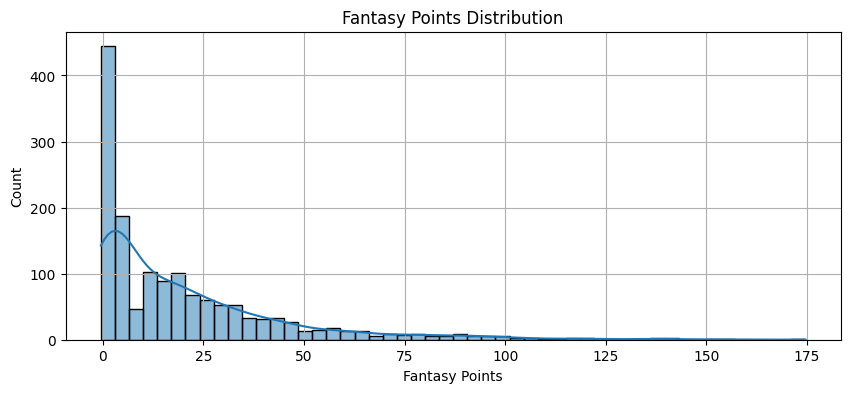

In [ ]:
# Plot Fantasy Points
plt.figure(figsize=(10, 4))
sns.histplot(df['CalculatedFantasyPoints_StdPPPRIDP'], bins=50, kde=True)
plt.title('Fantasy Points Distribution')
plt.xlabel('Fantasy Points')
plt.ylabel('Count')
plt.grid(True)
plt.show()

Given that there is so much data for players who barely scored fantasy points or had a significantly negative impact on team performance through VOR, we have decided to try to limit the number of players in the data to a more reasonable number given roster slots typically available in this type of fantasy league format.

In [ ]:
# Sort df by VOR
df = df.sort_values(by='VOR', ascending=False)

# Reset the index
df = df.reset_index(drop=True)

# Define the player distribution
position_limits = {
    'QB': 24,
    'RB': 60,
    'WR': 84,
    'TE': 24,
    'LB': 72,
    'DL': 48,
    'DB': 72
}

# Initialize an empty list to store the selected players
selected_players = []

# Loop over each position and select the top players based on VOR
for position, limit in position_limits.items():
    # Filter the dataframe for the current position
    position_df = df[df['Position'] == position]

    # Select the top `limit` players for that position based on VOR
    top_players = position_df.head(limit)

    # Add the selected players to the list
    selected_players.append(top_players)

# Concatenate all selected players into one dataframe
df_selected_players = pd.concat(selected_players)

# Reset index for the final DataFrame
df_selected_players.reset_index(drop=True, inplace=True)

# Print the final selected player count
print(f"Total selected players: {len(df_selected_players)}")

Total selected players: 384


In [ ]:
df_selected_players.head()

,Name,Team,Position,PassingYards,PassingTouchdowns,PassingInterceptions,RushingYards,RushingTouchdowns,ReceivingYards,ReceivingTouchdowns,...,Sacks,Interceptions,ForcedFumbles,DefensiveTouchdowns,CalculatedFantasyPoints_StdPPPRIDP,replacement_points,VOR,Cluster,Tier,TierLabel
0,L.Jackson,BAL,QB,1710.5,16.8,0.7,375.2,0.7,0.0,0.0,...,0.0,0.0,0,0.0,174.64,97.38,77.26,2,0,Tier 1 – Elite
1,J.Burrow,CIN,QB,2016.4,17.6,1.5,82.4,0.3,0.0,0.0,...,0.0,0.0,0,0.0,156.50,97.38,59.12,2,0,Tier 1 – Elite
2,B.Mayfield,TB,QB,1845.0,16.8,2.7,155.0,0.5,0.0,0.0,...,0.0,0.0,0,0.0,153.50,97.38,56.12,2,0,Tier 1 – Elite
3,J.Allen,BUF,QB,1529.7,11.5,1.0,217.7,2.0,1.2,0.2,...,0.0,0.0,0,0.0,139.88,97.38,42.50,2,0,Tier 1 – Elite
4,J.Daniels,WAS,QB,1462.9,10.2,1.5,365.3,1.0,0.0,0.0,...,0.0,0.0,0,0.0,139.05,97.38,41.67,2,0,Tier 1 – Elite


In [ ]:
df_selected_players.tail()

,Name,Team,Position,PassingYards,PassingTouchdowns,PassingInterceptions,RushingYards,RushingTouchdowns,ReceivingYards,ReceivingTouchdowns,...,Sacks,Interceptions,ForcedFumbles,DefensiveTouchdowns,CalculatedFantasyPoints_StdPPPRIDP,replacement_points,VOR,Cluster,Tier,TierLabel
379,J.Brownlee Jr.,TEN,DB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,0,0.0,30.9,37.0,-6.1,0,1,Tier 2 – High-End Starters
380,C.Bryant,SEA,DB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.5,0,0.2,30.6,37.0,-6.4,0,1,Tier 2 – High-End Starters
381,W.Harris,NO,DB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,0,0.0,30.5,37.0,-6.5,0,1,Tier 2 – High-End Starters
382,M.Hilton,CIN,DB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,0,0.0,30.5,37.0,-6.5,0,1,Tier 2 – High-End Starters
383,P.Locke,DEN,DB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2,0.0,0,0.0,30.3,37.0,-6.7,0,1,Tier 2 – High-End Starters


In [ ]:
min_vor_players = df_selected_players.sort_values('VOR').head(10)
print(min_vor_players[['Name', 'Position', 'VOR']])

            Name Position    VOR
23  A.Richardson       QB -40.61
22  T.Tagovailoa       QB -38.35
21        D.Maye       QB -36.19
20       B.Young       QB -35.16
19     K.Cousins       QB -33.85
83     R.Johnson       RB -31.48
82     G.Edwards       RB -31.13
81       N.Chubb       RB -30.91
80    K.Gainwell       RB -29.54
79     M.Sanders       RB -29.22


Now that we have limited the data to a more reasonable number of players per position given the league settings, we can evaluate the distibution of data again to ensure improvement in quality of the data.

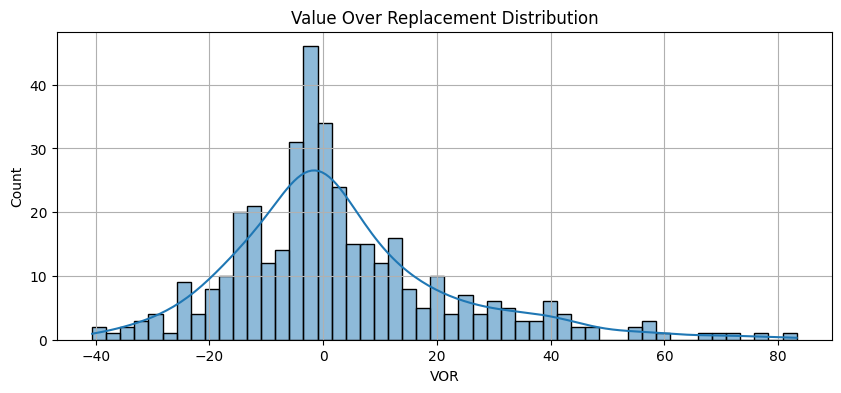

In [ ]:
# Check VOR distribution to eliminate players who either did not play enough
# or whose VOR is so low its unreasonable
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot VOR
plt.figure(figsize=(10, 4))
sns.histplot(df_selected_players['VOR'], bins=50, kde=True)
plt.title('Value Over Replacement Distribution')
plt.xlabel('VOR')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## **Perform Cluster Analysis**

### **Elbow Method**

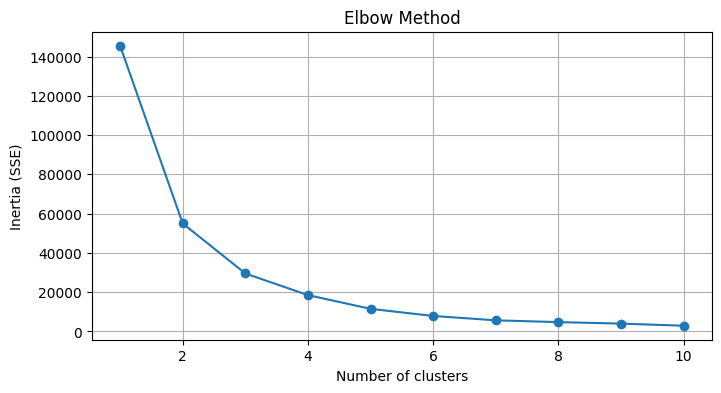

In [ ]:
# Import required function
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Isolate fantasy points as what we
X = df_selected_players[['VOR']]

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (SSE)')
plt.grid(True)
plt.show()

Looking at the output of this figure, the inertia seems to drop off (you can see an elbow) significantly after 4 clusters, so 4 clusters would be the recommended figure for this method.

### **Silhoutte Method**

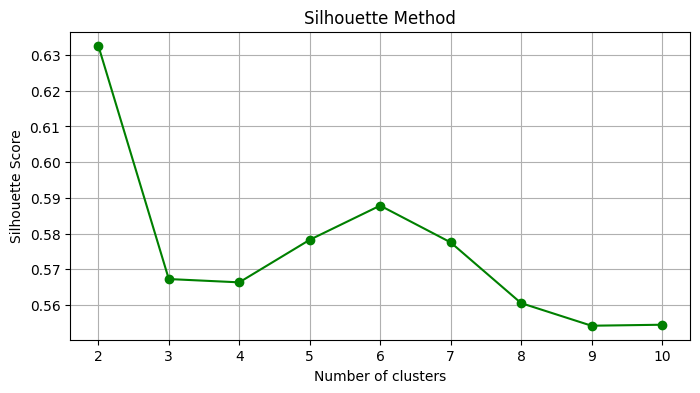

In [ ]:
# Import required function
from sklearn.metrics import silhouette_score

# Create empty object to hold silhoutte scores
silhouette_scores = []
K_range = range(2, 11)  # Silhouette is undefined for k=1

# Run a loop to calculate silhoutte scores
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Graph the output to determine optimal cluster count
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

This method suggests strongly that there should only by 2 clusters, but that does not make sense given our analysis, so we should also consider to localized peak of 6 clusters as well.

### **Gap Statistic**

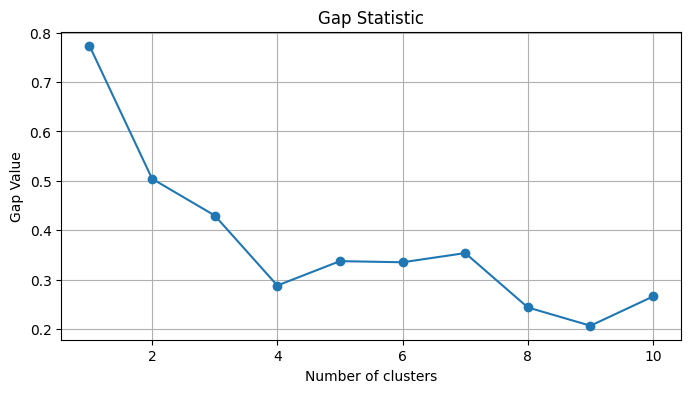

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

def compute_gap_statistic(X, refs=None, n_refs=10, max_clusters=10):

    shape = X.shape
    if refs is None:
        tops = X.max(axis=0)
        bottoms = X.min(axis=0)
        dists = tops - bottoms
        refs = np.random.rand(n_refs, shape[0], shape[1]) * dists + bottoms

    gaps = []
    deviations = []

    for k in range(1, max_clusters + 1):
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(X)
        orig_dispersion = np.mean(np.min(pairwise_distances(X, km.cluster_centers_), axis=1))

        ref_disps = np.zeros(n_refs)
        for i in range(n_refs):
            km.fit(refs[i])
            ref_disp = np.mean(np.min(pairwise_distances(refs[i], km.cluster_centers_), axis=1))
            ref_disps[i] = ref_disp

        gap = np.log(np.mean(ref_disps)) - np.log(orig_dispersion)
        sdk = np.std(np.log(ref_disps)) * np.sqrt(1 + 1/n_refs)

        gaps.append(gap)
        deviations.append(sdk)

    return gaps, deviations

# Example usage:
gaps, deviations = compute_gap_statistic(X.values, n_refs=10, max_clusters=10)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), gaps, marker='o')
plt.title('Gap Statistic')
plt.xlabel('Number of clusters')
plt.ylabel('Gap Value')
plt.grid(True)
plt.show()

Once again, we have two areas where the optimal number of clusters might be, where the gap statistic finds its minimum initially at 4, and then again at 8-9, so either figure could be considered.

### **Cluster Analysis**

Given that the Elbow Method clearly recommends 4 clusters as the best number and the gap statistic sets an early recommendation of using 4 clusters, we have elected to choose 4 clusters for our analysis. We also considered using 6, taking the Silhoutte Method into consideration, but 4 is still a reasonable, stable number of clusters after the sharp dropoff from 2 in that method.

             Name Team Position  CalculatedFantasyPoints_StdPPPRIDP    VOR  \
84        J.Chase  CIN       WR                              141.84  83.24   
0       L.Jackson  BAL       QB                              174.64  77.26   
24      S.Barkley  PHI       RB                              121.90  71.01   
25        J.Gibbs  DET       RB                              120.59  69.70   
26     B.Robinson  ATL       RB                              118.27  67.38   
1        J.Burrow  CIN       QB                              156.50  59.12   
85    J.Jefferson  MIN       WR                              115.65  57.05   
27        D.Henry  BAL       RB                              107.47  56.58   
2      B.Mayfield   TB       QB                              153.50  56.12   
28       D.Achane  MIA       RB                              105.66  54.77   
86    A.St. Brown  DET       WR                              112.23  53.63   
29       J.Jacobs   GB       RB                               98

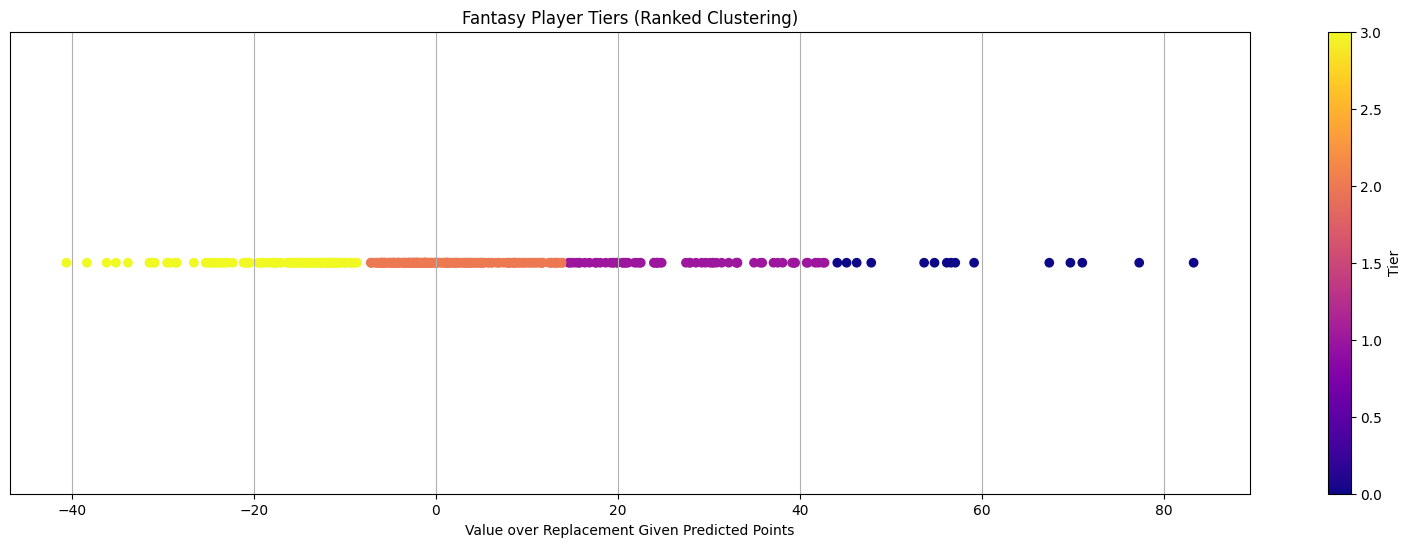

In [ ]:
# Import necessaary function
from sklearn.cluster import KMeans

# Run K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=418)
df_selected_players['Cluster'] = kmeans.fit_predict(X)

# Re-rank clusters by average fantasy points
cluster_summary = df_selected_players.groupby('Cluster')['VOR'].mean().sort_values(ascending=False)
tier_map = {old: new for new, old in enumerate(cluster_summary.index)}
df_selected_players['Tier'] = df_selected_players['Cluster'].map(tier_map)

# View top players by calculated fantasy points
print(df_selected_players[['Name', 'Team', 'Position', 'CalculatedFantasyPoints_StdPPPRIDP', 'VOR', 'Cluster', 'Tier']]
      .sort_values(by='VOR', ascending=False)
      .head(20))

# Visualize the cluster tiers
plt.figure(figsize=(20, 6))
scatter = plt.scatter(df_selected_players['VOR'], [0]*len(df_selected_players), c=df_selected_players['Tier'], cmap='plasma')
plt.xlabel('Value over Replacement Given Predicted Points')
plt.title('Fantasy Player Tiers (Ranked Clustering)')
plt.yticks([])
plt.grid(True)
plt.colorbar(scatter, label='Tier')
plt.show()

In [ ]:
# Get average CalculatedFantasyPoints_StdPPPRIDP and VOR for each tier
tier_stats = df_selected_players.groupby('Tier').agg({'CalculatedFantasyPoints_StdPPPRIDP': 'mean', 'VOR': 'mean'}).reset_index()

# Print the results
print(tier_stats)

   Tier  CalculatedFantasyPoints_StdPPPRIDP        VOR
0     0                          121.808667  59.273333
1     1                           83.472031  27.169844
2     2                           42.629760   1.332500
3     3                           38.216701 -17.708660


Looking at the average statistics for each tier in the cluster, we can see that the first tier seems to include players that significantly overperform their position, giving them high value at the beginning of a draft. The second tier seems to also outperform their peers, but on a much smaller scale. The third tier seems to perform averagely. The fourth tier seems to include players who perform severely worse than expected, which can largely be explained by the fact that many of the injury-ridden players are included in that tier.

In [ ]:
# Optional: Add readable labels (top to bottom)
tier_labels = [
    "Tier 1 – Elite",
    "Tier 2 – High-End Starters",
    "Tier 3 – Average Performers",
    "Tier 4 – Negative Performers"
]
# Apply TierLabel to the data frame
df_selected_players['TierLabel'] = df_selected_players['Tier'].map(lambda x: tier_labels[x])

In [ ]:
df_selected_players.head()

,Name,Team,Position,PassingYards,PassingTouchdowns,PassingInterceptions,RushingYards,RushingTouchdowns,ReceivingYards,ReceivingTouchdowns,...,Sacks,Interceptions,ForcedFumbles,DefensiveTouchdowns,CalculatedFantasyPoints_StdPPPRIDP,replacement_points,VOR,Cluster,Tier,TierLabel
0,L.Jackson,BAL,QB,1710.5,16.8,0.7,375.2,0.7,0.0,0.0,...,0.0,0.0,0,0.0,174.64,97.38,77.26,1,0,Tier 1 – Elite
1,J.Burrow,CIN,QB,2016.4,17.6,1.5,82.4,0.3,0.0,0.0,...,0.0,0.0,0,0.0,156.50,97.38,59.12,1,0,Tier 1 – Elite
2,B.Mayfield,TB,QB,1845.0,16.8,2.7,155.0,0.5,0.0,0.0,...,0.0,0.0,0,0.0,153.50,97.38,56.12,1,0,Tier 1 – Elite
3,J.Allen,BUF,QB,1529.7,11.5,1.0,217.7,2.0,1.2,0.2,...,0.0,0.0,0,0.0,139.88,97.38,42.50,3,1,Tier 2 – High-End Starters
4,J.Daniels,WAS,QB,1462.9,10.2,1.5,365.3,1.0,0.0,0.0,...,0.0,0.0,0,0.0,139.05,97.38,41.67,3,1,Tier 2 – High-End Starters


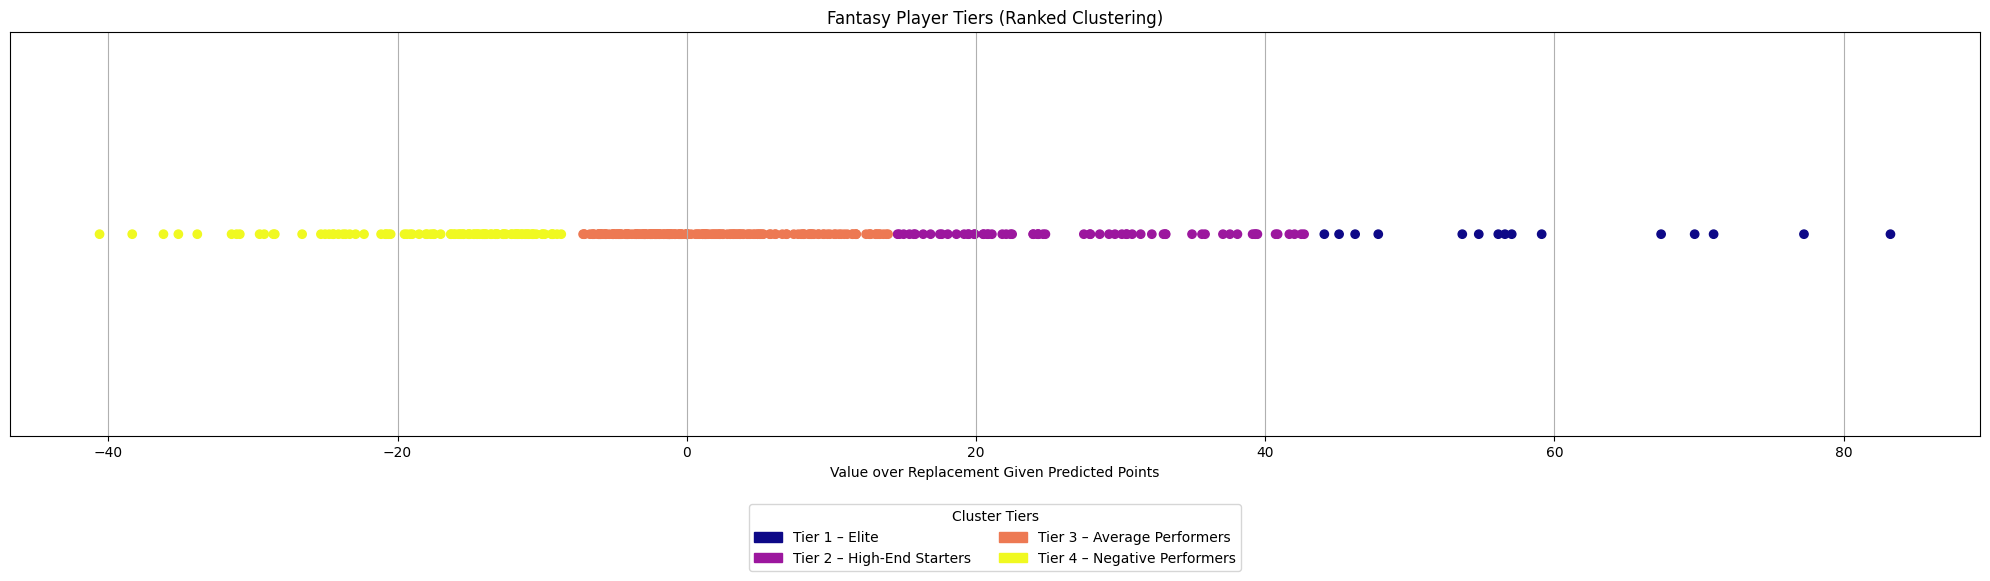

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Ensure TierLabels are created
tier_labels = [
    "Tier 1 – Elite",
    "Tier 2 – High-End Starters",
    "Tier 3 – Average Performers",
    "Tier 4 – Negative Performers"
]
df_selected_players['TierLabel'] = df_selected_players['Tier'].map(lambda x: tier_labels[x])

# Get unique tiers in order
unique_tiers = sorted(df_selected_players['Tier'].unique())
colors = [plt.cm.plasma(scatter_norm) for scatter_norm in
          plt.Normalize(min(unique_tiers), max(unique_tiers))(unique_tiers)]

# Create figure and scatter plot
plt.figure(figsize=(20, 6))
scatter = plt.scatter(
    df_selected_players['VOR'],
    [0] * len(df_selected_players),
    c=df_selected_players['Tier'],
    cmap='plasma'
)

# Remove y-axis and label the rest
plt.yticks([])
plt.grid(True)
plt.xlabel('Value over Replacement Given Predicted Points')
plt.title('Fantasy Player Tiers (Ranked Clustering)')

# Create discrete legend with readable labels
legend_handles = [
    mpatches.Patch(color=plt.cm.plasma(plt.Normalize(min(unique_tiers), max(unique_tiers))(tier)),
                   label=tier_labels[tier]) for tier in unique_tiers
]

plt.legend(
    handles=legend_handles,
    title='Cluster Tiers',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True
)

plt.tight_layout()
plt.show()

<ipython-input-33-7f3f39630fa8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='plasma')


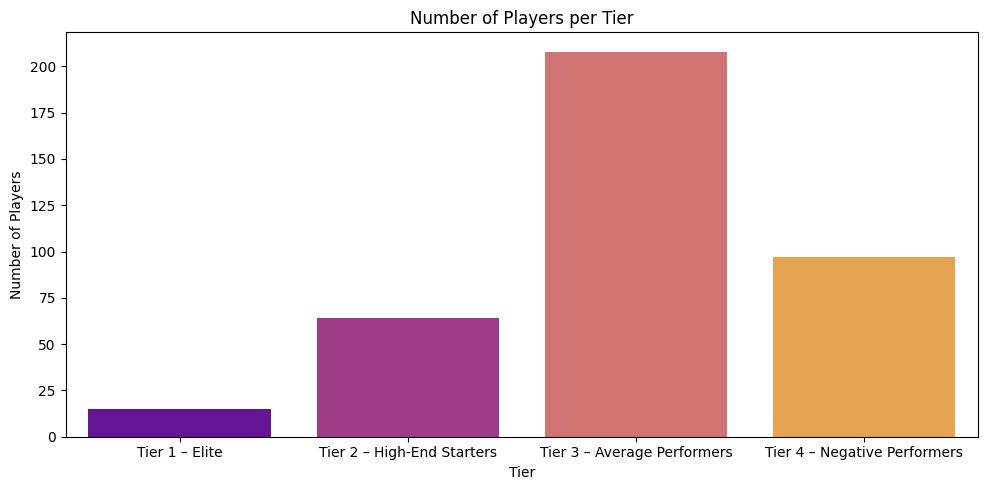

In [ ]:
# Count players per tier label
tier_counts = df_selected_players['TierLabel'].value_counts().reindex([
    "Tier 1 – Elite",
    "Tier 2 – High-End Starters",
    "Tier 3 – Average Performers",
    "Tier 4 – Negative Performers"
])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=tier_counts.index, y=tier_counts.values, palette='plasma')

plt.title('Number of Players per Tier')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show();

## **Comparison to Fantasy Pros**

We will end by evaluating our analysis be comparing our tier system to that of FantasyPros, from which we have scraped our data.

In [ ]:
# Read in the fantasy pros data
fantpros = pd.read_csv('fantasypros_ppr.csv')
fantpros

FileNotFoundError: [Errno 2] No such file or directory: 'fantasypros_ppr.csv'

In [ ]:
# Drop the name column
fantpros = fantpros.drop(columns=['Name'])

# Rename the Team/Position Column to 'Name/Team'
fantpros = fantpros.rename(columns={'Team/Position': 'Name/Team'})

# Rename the Bye Week column to Position Rank
fantpros = fantpros.rename(columns={'Bye Week': 'Position Rank'})

# Separate Name and Team
fantpros[['Name', 'Team']] = fantpros['Name/Team'].str.split('(', expand=True)

# Drop Name/Team column
fantpros = fantpros.drop(columns=['Name/Team'])

# Drop the last character in the Team column
fantpros['Team'] = fantpros['Team'].str.replace(r'\)$', '', regex=True)

# Drop any records where 'Tier' == 0
fantpros = fantpros[fantpros['Tier'] != 0]

fantpros

,Rank,Position Rank,Best Rank,Worst Rank,Tier,Name,Team
0,1,WR1,2,2,1,Ja'Marr Chase,CIN
1,2,RB1,1,8,2,Saquon Barkley,PHI
2,3,RB2,1,8,1,Bijan Robinson,ATL
3,4,WR2,4,4,1,Justin Jefferson,MIN
4,5,RB3,3,8,2,Jahmyr Gibbs,DET
...,...,...,...,...,...,...,...
406,407,QB46,323,382,16,Joe Milton III,DAL
408,409,TE56,344,381,16,Elijah Higgins,ARI
409,410,TE57,354,389,16,Grant Calcaterra,PHI
410,411,TE58,356,394,16,Stone Smartt,NYJ


In [ ]:
# Fix naming conventions to match other file
suffixes = ['Jr.', 'Sr.', 'II', 'III', 'IV']

# Naming convention change
fantpros['Name'] = fantpros['Name'].str.strip().str.split().apply(
    lambda x: (
        f"{x[0][0]}.{x[-2]} {x[-1]}" if len(x) >= 3 and x[-1] in suffixes
        else f"{x[0][0]}.{x[-2]}-{x[-1]}" if len(x) >= 3 and '-' in x[-2]
        else f"{x[0][0]}.{x[-1]}" if len(x) >= 2
        else x[0]  # fallback for single-word names
    )
)

# Manually Change Inconsistencies
# Change 'Name' P.Mahomes II' to 'P.Mahomes'
fantpros.loc[fantpros['Name'] == 'P.Mahomes II', 'Name'] = 'P.Mahomes'

# Change Name A.Jones Sr. to 'A.Jones'
fantpros.loc[fantpros['Name'] == 'A.Jones Sr.', 'Name'] = 'A.Jones'

In [ ]:
# Make a new data frame that only keeps 'Name', 'Team', and 'Tier'
fantpros_df = fantpros[['Name', 'Team', 'Tier']]

In [ ]:
# Make a new data frame for df_selected_players that only keeps 'Name', 'Team', 'CalculatedFantasyPoints_StdPPPRIDP', 'VOR', and 'TierLabel'
df_tomerge = df_selected_players[['Name', 'Team', 'VOR', 'TierLabel']]

In [ ]:
# Merge the two dataframes on 'Name' where we want to keep all records from fantpros_df
merged_df = fantpros_df.merge(df_tomerge, on='Name', how='left')
merged_df

,Name,Team_x,Tier,Team_y,VOR,TierLabel
0,J.Chase,CIN,1,CIN,83.24,Tier 1 – Elite
1,S.Barkley,PHI,2,PHI,71.01,Tier 1 – Elite
2,B.Robinson,ATL,1,ATL,67.38,Tier 1 – Elite
3,J.Jefferson,MIN,1,MIN,57.05,Tier 1 – Elite
4,J.Gibbs,DET,2,DET,69.70,Tier 1 – Elite
...,...,...,...,...,...,...
407,J.Milton III,DAL,16,NaN,NaN,NaN
408,E.Higgins,ARI,16,NaN,NaN,NaN
409,G.Calcaterra,PHI,16,NaN,NaN,NaN
410,S.Smartt,NYJ,16,NaN,NaN,NaN


In [ ]:
# Rename Team_x 'Team_2025' and Team_y 'Team_2026
merged_df = merged_df.rename(columns={'Team_x': 'Team_2026', 'Team_y': 'Team_2025'})
merged_df

,Name,Team_2026,Tier,Team_2025,VOR,TierLabel
0,J.Chase,CIN,1,CIN,83.24,Tier 1 – Elite
1,S.Barkley,PHI,2,PHI,71.01,Tier 1 – Elite
2,B.Robinson,ATL,1,ATL,67.38,Tier 1 – Elite
3,J.Jefferson,MIN,1,MIN,57.05,Tier 1 – Elite
4,J.Gibbs,DET,2,DET,69.70,Tier 1 – Elite
...,...,...,...,...,...,...
407,J.Milton III,DAL,16,NaN,NaN,NaN
408,E.Higgins,ARI,16,NaN,NaN,NaN
409,G.Calcaterra,PHI,16,NaN,NaN,NaN
410,S.Smartt,NYJ,16,NaN,NaN,NaN


In [ ]:
# Order the data frame so that the fields go 'Name', 'Team_2025', 'Team_2026', 'CalculatedFantasyPoints_StdPPPRIDP',
# 'VOR', 'Tier', 'TierLabel'
merged_df = merged_df[['Name', 'Team_2025', 'Team_2026', 'VOR', 'Tier', 'TierLabel']]
merged_df

,Name,Team_2025,Team_2026,VOR,Tier,TierLabel
0,J.Chase,CIN,CIN,83.24,1,Tier 1 – Elite
1,S.Barkley,PHI,PHI,71.01,2,Tier 1 – Elite
2,B.Robinson,ATL,ATL,67.38,1,Tier 1 – Elite
3,J.Jefferson,MIN,MIN,57.05,1,Tier 1 – Elite
4,J.Gibbs,DET,DET,69.70,2,Tier 1 – Elite
...,...,...,...,...,...,...
407,J.Milton III,NaN,DAL,NaN,16,NaN
408,E.Higgins,NaN,ARI,NaN,16,NaN
409,G.Calcaterra,NaN,PHI,NaN,16,NaN
410,S.Smartt,NaN,NYJ,NaN,16,NaN


In [ ]:
# Check missing values
merged_df.isnull().sum()

,0
Name,0
Team_2025,209
Team_2026,0
VOR,209
Tier,0
TierLabel,209


In [ ]:
merged_df = merged_df[~((merged_df['Tier'] >= 10) & (merged_df['VOR'].isna()))]
merged_df.isnull().sum()

,0
Name,0
Team_2025,21
Team_2026,0
VOR,21
Tier,0
TierLabel,21


In [ ]:
# Print records where there is missing data
merged_df[merged_df['VOR'].isna()]

,Name,Team_2025,Team_2026,VOR,Tier,TierLabel
6,A.Jeanty,NaN,LV,NaN,3,NaN
21,C.McCaffrey,NaN,SF,NaN,4,NaN
37,T.Hunter,NaN,JAC,NaN,7,NaN
42,T.McMillan,NaN,CAR,NaN,7,NaN
48,O.Hampton,NaN,LAC,NaN,7,NaN
50,R.Rice,NaN,KC,NaN,5,NaN
59,T.Henderson,NaN,NE,NaN,7,NaN
62,Q.Judkins,NaN,CLE,NaN,8,NaN
71,T.Hockenson,NaN,MIN,NaN,6,NaN
73,I.Pacheco,NaN,KC,NaN,7,NaN


In [ ]:
# Keep the rookies as data points and eliminate other players, as they were likely
# removed from the data during dimension reduction prior to clustering
players_to_drop = ['C.McCaffrey', 'R.Rice', 'T.Hockenson', 'I.Pacheco', 'K.Johnson', 'C.Olave',
                   'J.Fields', 'B.Aiyuk', 'E.Engram', 'D.Prescott', 'T.Lawrence', 'D.Goedert',
                   'D.Kincaid', 'C.Kirk']

# Drop players in list
# Keep rookies to show for limitation of the model
merged_df = merged_df[~merged_df['Name'].isin(players_to_drop)]

# For any null values in any field, replace with 'Rookie'
merged_df.fillna('Rookie', inplace=True)

# Change 'Team_2025' to DET for the record on index 8
merged_df.loc[8, 'Team_2025'] = 'DET'

# Examine the first records to compare tiered evaluation for each source
merged_df.head(20)

<ipython-input-314-4a964f1e5db2>:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rookie' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merged_df.fillna('Rookie', inplace=True)
<ipython-input-314-4a964f1e5db2>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df.fillna('Rookie', inplace=True)


,Name,Team_2025,Team_2026,VOR,Tier,TierLabel
0,J.Chase,CIN,CIN,83.24,1,Tier 1 – Elite
1,S.Barkley,PHI,PHI,71.01,2,Tier 1 – Elite
2,B.Robinson,ATL,ATL,67.38,1,Tier 1 – Elite
3,J.Jefferson,MIN,MIN,57.05,1,Tier 1 – Elite
4,J.Gibbs,DET,DET,69.7,2,Tier 1 – Elite
5,C.Lamb,DAL,DAL,40.72,2,Tier 2 – High-End Starters
6,A.Jeanty,Rookie,LV,Rookie,3,Rookie
7,P.Nacua,LAR,LAR,20.78,2,Tier 2 – High-End Starters
8,A.Brown,DET,DET,20.54,2,Tier 2 – High-End Starters
9,N.Collins,HOU,HOU,18.05,3,Tier 2 – High-End Starters
